In [1]:
!pip install --upgrade scikit-learn xgboost

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("final_xgboost_data_v3.csv")
df.head()

,City,PM2.5,PM10,NO,NO2,NH3,CO,SO2,O3,Month,Seasons,AQI_calculated,AQI_lag1,AQI_lag3,AQI_lag7,DayOfWeek,rolling_mean_7,AQI_tomorrow
0,Ahmedabad,154.0,181.5,15.598333,95.5,0.0,67500.0,61.5,16.0,3,Spring,326,341.0,471.0,497.0,3,392.428571,341.0
1,Ahmedabad,173.0,181.5,15.598333,104.0,0.0,93000.0,63.7,25.7,3,Spring,341,326.0,493.0,376.0,4,387.428571,407.0
2,Ahmedabad,267.0,181.5,15.598333,155.0,0.0,91000.0,105.0,14.5,3,Spring,407,341.0,341.0,389.0,5,390.000000,372.0
3,Ahmedabad,214.0,181.5,15.598333,131.0,0.0,60000.0,107.0,45.9,3,Spring,372,407.0,326.0,351.0,6,393.000000,390.0
4,Ahmedabad,237.0,181.5,15.598333,121.0,0.0,52000.0,76.3,77.3,3,Spring,390,372.0,341.0,471.0,0,381.428571,486.0


In [4]:
#GROUPED CHRONOLOGICAL SPLIT

def chronological_city_split(dataframe, test_size=0.2):
    """
    Splits data into train/test chronologically for each individual city.
    Assumes the dataframe is already sorted by Time.
    """
    train_chunks = []
    test_chunks = []
    
    for city, group in dataframe.groupby('City'):
        split_index = int(len(group) * (1 - test_size))
    
        train_chunks.append(group.iloc[:split_index])
        
        test_chunks.append(group.iloc[split_index:])
        
    return pd.concat(train_chunks), pd.concat(test_chunks)

train_df, test_df = chronological_city_split(df, test_size=0.2)

print(f"Training rows: {len(train_df)}")
print(f"esting rows: {len(test_df)}")

x_train = train_df.drop(columns=['AQI_tomorrow'])
y_train = train_df['AQI_tomorrow']

x_test = test_df.drop(columns=['AQI_tomorrow'])
y_test = test_df['AQI_tomorrow']



Training rows: 15784
esting rows: 3951


In [5]:
categorical_features = ['City', 'Seasons']
numeric_features = [col for col in x_train.columns if col not in categorical_features]

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         categorical_features)
    ],
    remainder='passthrough'
)

In [7]:
xgb_model = XGBRegressor()


In [8]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb_model)
])

In [9]:
model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['City','PM2.5','PM10',...,'AQI_lag7','DayOfWeek','rolling_mean_7']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis con

In [10]:
y_pred = model.predict(x_test)

In [11]:
print(f"MAE : {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"r2_score: {r2_score(y_test, y_pred)}")

MAE : 20.924144721701005
RMSE : 33.70715514682472
r2_score: 0.7463115823661788


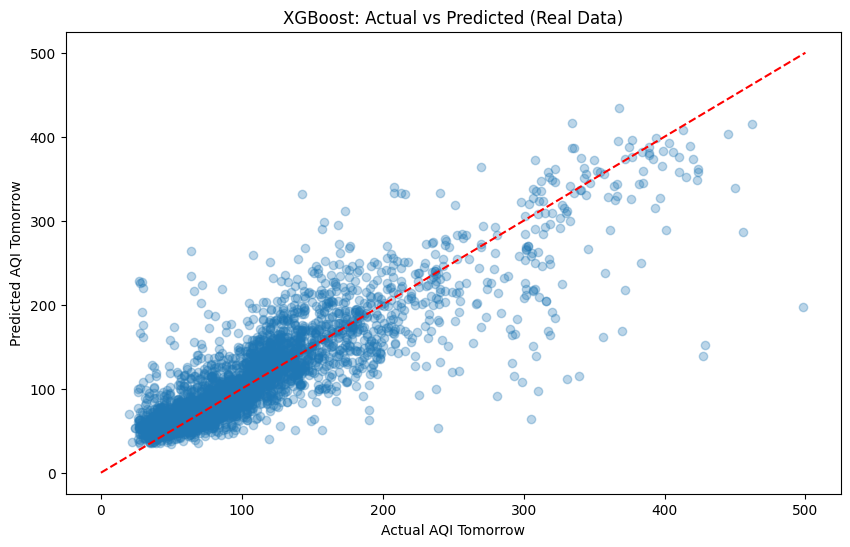

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0, 500], [0, 500], 'r--')
plt.xlabel('Actual AQI Tomorrow')
plt.ylabel('Predicted AQI Tomorrow')
plt.title('XGBoost: Actual vs Predicted (Real Data)')
plt.show()

In [13]:
print(x_train.columns.tolist())

['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NH3', 'CO', 'SO2', 'O3', 'Month', 'Seasons', 'AQI_calculated', 'AQI_lag1', 'AQI_lag3', 'AQI_lag7', 'DayOfWeek', 'rolling_mean_7']


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            19735 non-null  object 
 1   PM2.5           19735 non-null  float64
 2   PM10            19735 non-null  float64
 3   NO              19735 non-null  float64
 4   NO2             19735 non-null  float64
 5   NH3             19735 non-null  float64
 6   CO              19735 non-null  float64
 7   SO2             19735 non-null  float64
 8   O3              19735 non-null  float64
 9   Month           19735 non-null  int64  
 10  Seasons         19735 non-null  object 
 11  AQI_calculated  19735 non-null  int64  
 12  AQI_lag1        19735 non-null  float64
 13  AQI_lag3        19735 non-null  float64
 14  AQI_lag7        19735 non-null  float64
 15  DayOfWeek       19735 non-null  int64  
 16  rolling_mean_7  19735 non-null  float64
 17  AQI_tomorrow    19735 non-null 

In [15]:
import optuna
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'random_state': 42,
        'n_jobs': -1
    }

    tscv = TimeSeriesSplit(n_splits=3)
    cv_rmse_scores = []

    for train_index, val_index in tscv.split(x_train):
        X_tr, X_val = x_train.iloc[train_index], x_train.iloc[val_index]
        y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', XGBRegressor(**params))
        ])

        pipeline.fit(X_tr, y_tr)
        preds = pipeline.predict(X_val)
        
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_rmse_scores.append(rmse)

    return np.mean(cv_rmse_scores)

study = optuna.create_study(direction='minimize')

study.optimize(objective, n_trials=100, show_progress_bar=True)

print("\nBest Parameters Found:")
print(study.best_params)
print(f"Best Cross-Validation RMSE: {study.best_value:.2f}")

C:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-06-09 20:01:48,851] A new study created in memory with name: no-name-866a9a5d-0b51-46c3-bc02-6da758aa75fb
Best trial: 0. Best value: 63.4502:   1%|▍                                             | 1/100 [00:15<25:17, 15.33s/it]

[I 2026-06-09 20:02:04,182] Trial 0 finished with value: 63.45019542076134 and parameters: {'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.18664367013417182, 'subsample': 0.9405662011670755, 'colsample_bytree': 0.5066269411684052, 'min_child_weight': 1, 'gamma': 2.399466007088339, 'reg_alpha': 0.8728939617103745, 'reg_lambda': 9.954725999773725e-05}. Best is trial 0 with value: 63.45019542076134.


Best trial: 1. Best value: 59.0398:   2%|▉                                             | 2/100 [00:21<16:27, 10.08s/it]

[I 2026-06-09 20:02:10,579] Trial 1 finished with value: 59.03983708960778 and parameters: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.012264817682294942, 'subsample': 0.9939334912504845, 'colsample_bytree': 0.8317274042487546, 'min_child_weight': 1, 'gamma': 9.052624725143875, 'reg_alpha': 0.000649735687801433, 'reg_lambda': 2.0920883697857877e-07}. Best is trial 1 with value: 59.03983708960778.


Best trial: 1. Best value: 59.0398:   3%|█▍                                            | 3/100 [00:28<14:07,  8.74s/it]

[I 2026-06-09 20:02:17,718] Trial 2 finished with value: 59.911387854501186 and parameters: {'n_estimators': 450, 'max_depth': 4, 'learning_rate': 0.04537820714099387, 'subsample': 0.6187549378072905, 'colsample_bytree': 0.9398215648469853, 'min_child_weight': 14, 'gamma': 8.881947581122043, 'reg_alpha': 1.891136561221221e-05, 'reg_lambda': 2.5708406402208373e-05}. Best is trial 1 with value: 59.03983708960778.


Best trial: 1. Best value: 59.0398:   4%|█▊                                            | 4/100 [00:45<18:54, 11.82s/it]

[I 2026-06-09 20:02:34,262] Trial 3 finished with value: 62.832627733253794 and parameters: {'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.041683278766477795, 'subsample': 0.6369914575806064, 'colsample_bytree': 0.9354705816072574, 'min_child_weight': 8, 'gamma': 9.323467468235712, 'reg_alpha': 5.616859588289882e-06, 'reg_lambda': 0.006983093299984847}. Best is trial 1 with value: 59.03983708960778.


Best trial: 4. Best value: 58.2026:   5%|██▎                                           | 5/100 [00:58<19:38, 12.41s/it]

[I 2026-06-09 20:02:47,699] Trial 4 finished with value: 58.202552602607206 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.013906786080290778, 'subsample': 0.8050164115376005, 'colsample_bytree': 0.8858016025509006, 'min_child_weight': 13, 'gamma': 0.90932472417671, 'reg_alpha': 0.0362892318712965, 'reg_lambda': 2.822858703492117e-06}. Best is trial 4 with value: 58.202552602607206.


Best trial: 4. Best value: 58.2026:   6%|██▊                                           | 6/100 [01:17<22:52, 14.60s/it]

[I 2026-06-09 20:03:06,577] Trial 5 finished with value: 64.17167494964451 and parameters: {'n_estimators': 1100, 'max_depth': 11, 'learning_rate': 0.22258931171563, 'subsample': 0.7080870197425942, 'colsample_bytree': 0.5333623146339181, 'min_child_weight': 7, 'gamma': 8.714640839101687, 'reg_alpha': 0.33975432423754437, 'reg_lambda': 1.366483129999582e-08}. Best is trial 4 with value: 58.202552602607206.


Best trial: 4. Best value: 58.2026:   7%|███▏                                          | 7/100 [01:55<34:36, 22.33s/it]

[I 2026-06-09 20:03:44,797] Trial 6 finished with value: 62.46773276943429 and parameters: {'n_estimators': 1300, 'max_depth': 8, 'learning_rate': 0.11122885930657656, 'subsample': 0.8021002527163406, 'colsample_bytree': 0.5251219585378032, 'min_child_weight': 3, 'gamma': 0.7956574322638199, 'reg_alpha': 7.091526527045361e-07, 'reg_lambda': 0.04807530559834305}. Best is trial 4 with value: 58.202552602607206.


Best trial: 7. Best value: 56.6956:   8%|███▋                                          | 8/100 [01:58<24:40, 16.09s/it]

[I 2026-06-09 20:03:47,493] Trial 7 finished with value: 56.69557352335527 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.04907354392721981, 'subsample': 0.564938346196973, 'colsample_bytree': 0.7291943025646305, 'min_child_weight': 5, 'gamma': 8.550661550467407, 'reg_alpha': 2.6950694680959158e-05, 'reg_lambda': 0.01213512762935981}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:   9%|████▏                                         | 9/100 [02:14<24:08, 15.91s/it]

[I 2026-06-09 20:04:03,080] Trial 8 finished with value: 71.53720230076291 and parameters: {'n_estimators': 300, 'max_depth': 11, 'learning_rate': 0.29800716361796675, 'subsample': 0.635341025178194, 'colsample_bytree': 0.9348089516715936, 'min_child_weight': 11, 'gamma': 8.48402369524967, 'reg_alpha': 8.144388420755961e-06, 'reg_lambda': 2.386348211727256e-07}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  10%|████▌                                        | 10/100 [02:57<36:39, 24.43s/it]

[I 2026-06-09 20:04:46,499] Trial 9 finished with value: 60.41410314783519 and parameters: {'n_estimators': 1300, 'max_depth': 8, 'learning_rate': 0.02126030086974172, 'subsample': 0.8826086214364476, 'colsample_bytree': 0.5292488941345774, 'min_child_weight': 5, 'gamma': 1.7779919886912798, 'reg_alpha': 8.499697770981504, 'reg_lambda': 1.483130614481589e-08}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  11%|████▉                                        | 11/100 [03:06<28:56, 19.51s/it]

[I 2026-06-09 20:04:54,911] Trial 10 finished with value: 62.462111320127526 and parameters: {'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.08791958326217192, 'subsample': 0.5157702179513883, 'colsample_bytree': 0.6918647555421754, 'min_child_weight': 10, 'gamma': 5.955609861195535, 'reg_alpha': 1.51919592098897e-08, 'reg_lambda': 3.345719176345515}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  12%|█████▍                                       | 12/100 [03:11<22:07, 15.09s/it]

[I 2026-06-09 20:04:59,909] Trial 11 finished with value: 58.19985661708628 and parameters: {'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.021389656447725475, 'subsample': 0.794529257730786, 'colsample_bytree': 0.7449613802674596, 'min_child_weight': 15, 'gamma': 4.1906414198928115, 'reg_alpha': 0.0030112883060747896, 'reg_lambda': 0.0042687421488193265}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  13%|█████▊                                       | 13/100 [03:16<17:34, 12.12s/it]

[I 2026-06-09 20:05:05,190] Trial 12 finished with value: 57.95942448469375 and parameters: {'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.029358429773083103, 'subsample': 0.5118854552911092, 'colsample_bytree': 0.7102393945079489, 'min_child_weight': 6, 'gamma': 4.668145447644322, 'reg_alpha': 0.0033201419601622427, 'reg_lambda': 0.006153263574609359}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  14%|██████▎                                      | 14/100 [03:34<19:55, 13.90s/it]

[I 2026-06-09 20:05:23,212] Trial 13 finished with value: 61.894136592709636 and parameters: {'n_estimators': 550, 'max_depth': 7, 'learning_rate': 0.029545364335196098, 'subsample': 0.5062471346294724, 'colsample_bytree': 0.6574495806846652, 'min_child_weight': 5, 'gamma': 6.037062127118279, 'reg_alpha': 0.009273887946050292, 'reg_lambda': 0.5295880274972704}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  15%|██████▊                                      | 15/100 [03:41<16:41, 11.78s/it]

[I 2026-06-09 20:05:30,081] Trial 14 finished with value: 62.02995566953737 and parameters: {'n_estimators': 100, 'max_depth': 12, 'learning_rate': 0.07875233162097607, 'subsample': 0.5704022299382681, 'colsample_bytree': 0.637344703101224, 'min_child_weight': 5, 'gamma': 4.383895713912805, 'reg_alpha': 0.0001315851374524898, 'reg_lambda': 0.0017266078131726202}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  16%|███████▏                                     | 16/100 [03:48<14:28, 10.34s/it]

[I 2026-06-09 20:05:37,060] Trial 15 finished with value: 60.1151335919669 and parameters: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.058606383596780984, 'subsample': 0.6981724890590091, 'colsample_bytree': 0.8028462209774273, 'min_child_weight': 7, 'gamma': 7.226229225481363, 'reg_alpha': 6.116533762902605e-07, 'reg_lambda': 0.14112677671306956}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  17%|███████▋                                     | 17/100 [04:35<29:49, 21.56s/it]

[I 2026-06-09 20:06:24,714] Trial 16 finished with value: 60.63991046132298 and parameters: {'n_estimators': 1000, 'max_depth': 9, 'learning_rate': 0.02878991269871374, 'subsample': 0.5554165317327099, 'colsample_bytree': 0.7284545519999283, 'min_child_weight': 3, 'gamma': 3.038706725685853, 'reg_alpha': 0.00029941548946946684, 'reg_lambda': 0.00056433913232681}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  18%|████████                                     | 18/100 [04:59<30:28, 22.30s/it]

[I 2026-06-09 20:06:48,747] Trial 17 finished with value: 62.29745555476831 and parameters: {'n_estimators': 650, 'max_depth': 5, 'learning_rate': 0.0329314211039936, 'subsample': 0.5761588344166869, 'colsample_bytree': 0.632095103572529, 'min_child_weight': 9, 'gamma': 6.3714222565322505, 'reg_alpha': 0.0902733519789682, 'reg_lambda': 0.04342574840729654}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  19%|████████▌                                    | 19/100 [05:51<41:55, 31.05s/it]

[I 2026-06-09 20:07:40,191] Trial 18 finished with value: 62.37146556333198 and parameters: {'n_estimators': 1500, 'max_depth': 7, 'learning_rate': 0.06296723101319533, 'subsample': 0.6913669656783834, 'colsample_bytree': 0.7939770315325018, 'min_child_weight': 3, 'gamma': 7.592750440719239, 'reg_alpha': 5.0589618803473744e-08, 'reg_lambda': 4.652901355179827}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  20%|█████████                                    | 20/100 [06:09<36:04, 27.06s/it]

[I 2026-06-09 20:07:57,898] Trial 19 finished with value: 60.516345033617114 and parameters: {'n_estimators': 400, 'max_depth': 9, 'learning_rate': 0.017776637012914334, 'subsample': 0.5040693741354697, 'colsample_bytree': 0.9995120295501625, 'min_child_weight': 6, 'gamma': 5.061796145574157, 'reg_alpha': 0.0032438073273034955, 'reg_lambda': 5.362571071548372e-05}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  21%|█████████▍                                   | 21/100 [06:11<25:58, 19.73s/it]

[I 2026-06-09 20:08:00,544] Trial 20 finished with value: 68.27113770395668 and parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01054910226261573, 'subsample': 0.5989431344995035, 'colsample_bytree': 0.5716660309552613, 'min_child_weight': 12, 'gamma': 3.4808787347157253, 'reg_alpha': 3.9100132228433743e-05, 'reg_lambda': 0.008138288153728478}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  22%|█████████▉                                   | 22/100 [06:17<20:11, 15.53s/it]

[I 2026-06-09 20:08:06,301] Trial 21 finished with value: 60.13920916866684 and parameters: {'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.022104445317828982, 'subsample': 0.7830891057281419, 'colsample_bytree': 0.743287440040059, 'min_child_weight': 8, 'gamma': 4.353221538262005, 'reg_alpha': 0.002589620989863558, 'reg_lambda': 0.002422284073680002}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  23%|██████████▎                                  | 23/100 [06:28<18:01, 14.05s/it]

[I 2026-06-09 20:08:16,894] Trial 22 finished with value: 61.63509594220846 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.037141420956998225, 'subsample': 0.8583815802601988, 'colsample_bytree': 0.7102069217015337, 'min_child_weight': 15, 'gamma': 4.890124359864813, 'reg_alpha': 0.0007763816713941278, 'reg_lambda': 0.01772911024630527}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  24%|██████████▊                                  | 24/100 [06:48<20:12, 15.95s/it]

[I 2026-06-09 20:08:37,296] Trial 23 finished with value: 60.27280142558468 and parameters: {'n_estimators': 350, 'max_depth': 10, 'learning_rate': 0.017678153630860283, 'subsample': 0.7432694730677594, 'colsample_bytree': 0.7755876491074533, 'min_child_weight': 4, 'gamma': 9.94545676086333, 'reg_alpha': 0.019397183622360818, 'reg_lambda': 0.4187632533362686}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  25%|███████████▎                                 | 25/100 [06:55<16:32, 13.24s/it]

[I 2026-06-09 20:08:44,198] Trial 24 finished with value: 59.450962434801056 and parameters: {'n_estimators': 150, 'max_depth': 8, 'learning_rate': 0.02597767309195615, 'subsample': 0.859489374758579, 'colsample_bytree': 0.8430667106034957, 'min_child_weight': 9, 'gamma': 3.7440994174542226, 'reg_alpha': 0.00011234743274727962, 'reg_lambda': 0.0005032944587192795}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  26%|███████████▋                                 | 26/100 [07:02<14:14, 11.55s/it]

[I 2026-06-09 20:08:51,820] Trial 25 finished with value: 58.400433664055726 and parameters: {'n_estimators': 250, 'max_depth': 7, 'learning_rate': 0.016045454950045213, 'subsample': 0.6661925408096212, 'colsample_bytree': 0.6877685800324904, 'min_child_weight': 6, 'gamma': 5.457502651641806, 'reg_alpha': 1.993120795006098e-06, 'reg_lambda': 1.0445001703641294e-05}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  27%|████████████▏                                | 27/100 [07:20<16:06, 13.25s/it]

[I 2026-06-09 20:09:09,014] Trial 26 finished with value: 62.47385724601907 and parameters: {'n_estimators': 450, 'max_depth': 9, 'learning_rate': 0.045876303361688735, 'subsample': 0.7426194959671344, 'colsample_bytree': 0.6067422524412901, 'min_child_weight': 10, 'gamma': 7.276379850658337, 'reg_alpha': 0.0025524483558780104, 'reg_lambda': 0.0016560870251839464}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  28%|████████████▌                                | 28/100 [07:44<19:58, 16.65s/it]

[I 2026-06-09 20:09:33,607] Trial 27 finished with value: 59.51690171660238 and parameters: {'n_estimators': 550, 'max_depth': 11, 'learning_rate': 0.022792745912596574, 'subsample': 0.5303133647819711, 'colsample_bytree': 0.7553124168407422, 'min_child_weight': 15, 'gamma': 2.464717563570016, 'reg_alpha': 0.20014225848607523, 'reg_lambda': 0.0002601159343206313}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  29%|█████████████                                | 29/100 [08:03<20:24, 17.24s/it]

[I 2026-06-09 20:09:52,233] Trial 28 finished with value: 67.94622378117201 and parameters: {'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.1289875740449908, 'subsample': 0.5461319386041774, 'colsample_bytree': 0.6706937412786798, 'min_child_weight': 7, 'gamma': 0.09086196167219818, 'reg_alpha': 3.5811474523579745e-05, 'reg_lambda': 0.4952779426905817}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  30%|█████████████▌                               | 30/100 [08:40<27:06, 23.24s/it]

[I 2026-06-09 20:10:29,457] Trial 29 finished with value: 60.86166018082131 and parameters: {'n_estimators': 950, 'max_depth': 12, 'learning_rate': 0.054580556698541075, 'subsample': 0.9152147902881403, 'colsample_bytree': 0.8311678606378894, 'min_child_weight': 2, 'gamma': 6.49051641501957, 'reg_alpha': 0.9800203417467314, 'reg_lambda': 0.00016645709165229847}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  31%|█████████████▉                               | 31/100 [08:43<19:43, 17.16s/it]

[I 2026-06-09 20:10:32,413] Trial 30 finished with value: 57.00247207975699 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.03300806452273894, 'subsample': 0.8349636789498451, 'colsample_bytree': 0.6004918872066316, 'min_child_weight': 4, 'gamma': 2.4169708712707583, 'reg_alpha': 0.005260078802105976, 'reg_lambda': 0.08785896140004423}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  32%|██████████████▍                              | 32/100 [08:47<14:48, 13.06s/it]

[I 2026-06-09 20:10:35,908] Trial 31 finished with value: 58.121736610485605 and parameters: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03808073836414786, 'subsample': 0.8359645425970723, 'colsample_bytree': 0.5810285406219945, 'min_child_weight': 4, 'gamma': 2.1480698141975605, 'reg_alpha': 0.008010728687986695, 'reg_lambda': 0.08907034437377635}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  33%|██████████████▊                              | 33/100 [08:50<11:25, 10.24s/it]

[I 2026-06-09 20:10:39,578] Trial 32 finished with value: 58.410922042916674 and parameters: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03449231621113823, 'subsample': 0.8408623703246372, 'colsample_bytree': 0.6111149380453812, 'min_child_weight': 1, 'gamma': 2.0881998147976515, 'reg_alpha': 0.0006323206480576125, 'reg_lambda': 0.10072593382737555}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  34%|███████████████▎                             | 34/100 [08:54<09:04,  8.26s/it]

[I 2026-06-09 20:10:43,213] Trial 33 finished with value: 58.25205857806159 and parameters: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.04907849821626772, 'subsample': 0.9800825564074026, 'colsample_bytree': 0.5868458884465462, 'min_child_weight': 6, 'gamma': 2.790269290193371, 'reg_alpha': 0.022310263728532433, 'reg_lambda': 1.4086200922101946}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  35%|███████████████▋                             | 35/100 [08:59<07:51,  7.26s/it]

[I 2026-06-09 20:10:48,124] Trial 34 finished with value: 59.59517295028427 and parameters: {'n_estimators': 350, 'max_depth': 3, 'learning_rate': 0.07236707007577464, 'subsample': 0.9262919562402675, 'colsample_bytree': 0.5559513832255054, 'min_child_weight': 4, 'gamma': 1.73010988121536, 'reg_alpha': 0.010040680221423732, 'reg_lambda': 0.044147688551855795}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  36%|████████████████▏                            | 36/100 [09:03<06:54,  6.48s/it]

[I 2026-06-09 20:10:52,809] Trial 35 finished with value: 60.54811861188518 and parameters: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.038408169334454914, 'subsample': 0.8288442185717361, 'colsample_bytree': 0.5005076105806041, 'min_child_weight': 4, 'gamma': 1.245229371089917, 'reg_alpha': 0.06855646827532598, 'reg_lambda': 0.01006906378008733}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  37%|████████████████▋                            | 37/100 [09:14<08:12,  7.82s/it]

[I 2026-06-09 20:11:03,735] Trial 36 finished with value: 61.38210991441246 and parameters: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.042378845765518675, 'subsample': 0.7740162280024978, 'colsample_bytree': 0.6477573450313426, 'min_child_weight': 2, 'gamma': 3.2114829533878524, 'reg_alpha': 1.3199901315700213, 'reg_lambda': 0.21842426849770466}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  38%|█████████████████                            | 38/100 [09:20<07:21,  7.13s/it]

[I 2026-06-09 20:11:09,246] Trial 37 finished with value: 63.63809932752752 and parameters: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.09582924138749574, 'subsample': 0.8969589626294493, 'colsample_bytree': 0.6007559903032702, 'min_child_weight': 5, 'gamma': 0.10777205498728915, 'reg_alpha': 0.0009163541224176132, 'reg_lambda': 0.020050997391385775}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  39%|█████████████████▌                           | 39/100 [09:41<11:36, 11.42s/it]

[I 2026-06-09 20:11:30,706] Trial 38 finished with value: 60.34921923692173 and parameters: {'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.02815854538888182, 'subsample': 0.6077498562650199, 'colsample_bytree': 0.5552159626573917, 'min_child_weight': 2, 'gamma': 8.073906851308719, 'reg_alpha': 0.007938320256794596, 'reg_lambda': 1.3951095093131949}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  40%|██████████████████                           | 40/100 [09:48<09:53,  9.89s/it]

[I 2026-06-09 20:11:36,989] Trial 39 finished with value: 63.1995467626871 and parameters: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.15030088773138398, 'subsample': 0.9607926170121542, 'colsample_bytree': 0.7020984044428119, 'min_child_weight': 4, 'gamma': 3.7124718970875423, 'reg_alpha': 0.00026905382872439006, 'reg_lambda': 0.06583431603930408}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  41%|██████████████████▍                          | 41/100 [09:51<07:39,  7.79s/it]

[I 2026-06-09 20:11:39,913] Trial 40 finished with value: 57.768337725683836 and parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.06703853400774136, 'subsample': 0.7574080008017817, 'colsample_bytree': 0.6265621784236144, 'min_child_weight': 6, 'gamma': 1.281493861224457, 'reg_alpha': 2.0527210129625124e-05, 'reg_lambda': 0.0008496089139825233}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  42%|██████████████████▉                          | 42/100 [09:54<06:16,  6.49s/it]

[I 2026-06-09 20:11:43,374] Trial 41 finished with value: 57.660810119024525 and parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.050251054531276686, 'subsample': 0.7355332844217506, 'colsample_bytree': 0.6270940152700736, 'min_child_weight': 6, 'gamma': 1.1815061098999142, 'reg_alpha': 7.519678188273682e-06, 'reg_lambda': 0.0009150130777829605}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  43%|███████████████████▎                         | 43/100 [09:56<04:59,  5.25s/it]

[I 2026-06-09 20:11:45,716] Trial 42 finished with value: 57.90993335327398 and parameters: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.06241233593778399, 'subsample': 0.6498002230683302, 'colsample_bytree': 0.6756498696409563, 'min_child_weight': 6, 'gamma': 1.0134069256541138, 'reg_alpha': 6.209976500566841e-06, 'reg_lambda': 7.722664753393594e-05}. Best is trial 7 with value: 56.69557352335527.


Best trial: 7. Best value: 56.6956:  44%|███████████████████▊                         | 44/100 [10:00<04:34,  4.90s/it]

[I 2026-06-09 20:11:49,805] Trial 43 finished with value: 60.05728409244744 and parameters: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.06535058583711224, 'subsample': 0.6635612472675809, 'colsample_bytree': 0.6279977642263359, 'min_child_weight': 7, 'gamma': 0.8031599706905423, 'reg_alpha': 9.831907495476602e-06, 'reg_lambda': 5.642477467171561e-06}. Best is trial 7 with value: 56.69557352335527.


Best trial: 44. Best value: 56.1882:  45%|███████████████████▊                        | 45/100 [10:07<05:00,  5.46s/it]

[I 2026-06-09 20:11:56,540] Trial 44 finished with value: 56.18822653572793 and parameters: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.05102355071306597, 'subsample': 0.7215737866058137, 'colsample_bytree': 0.6708639897646915, 'min_child_weight': 7, 'gamma': 1.2803374217419696, 'reg_alpha': 1.6781867958040631e-06, 'reg_lambda': 3.3135838021000934e-05}. Best is trial 44 with value: 56.18822653572793.


Best trial: 44. Best value: 56.1882:  46%|████████████████████▏                       | 46/100 [10:14<05:19,  5.92s/it]

[I 2026-06-09 20:12:03,552] Trial 45 finished with value: 59.92070041435835 and parameters: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.051388068663483194, 'subsample': 0.7186540623433902, 'colsample_bytree': 0.6621521858272638, 'min_child_weight': 8, 'gamma': 1.4839033974049856, 'reg_alpha': 2.9479698882872343e-07, 'reg_lambda': 2.01013855303194e-05}. Best is trial 44 with value: 56.18822653572793.


Best trial: 44. Best value: 56.1882:  47%|████████████████████▋                       | 47/100 [10:16<04:13,  4.79s/it]

[I 2026-06-09 20:12:05,713] Trial 46 finished with value: 57.30109920007833 and parameters: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.0930754823930935, 'subsample': 0.7614188417082828, 'colsample_bytree': 0.6178973731974644, 'min_child_weight': 7, 'gamma': 2.5555001332274876, 'reg_alpha': 2.3856273208974027e-06, 'reg_lambda': 0.0009110600799745449}. Best is trial 44 with value: 56.18822653572793.


Best trial: 44. Best value: 56.1882:  48%|█████████████████████                       | 48/100 [10:19<03:42,  4.27s/it]

[I 2026-06-09 20:12:08,791] Trial 47 finished with value: 61.177862091815335 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.09938320401008184, 'subsample': 0.7306188744215957, 'colsample_bytree': 0.5446189491216907, 'min_child_weight': 7, 'gamma': 0.549629757365925, 'reg_alpha': 3.1269368676671203e-06, 'reg_lambda': 4.023911780803244e-05}. Best is trial 44 with value: 56.18822653572793.


Best trial: 44. Best value: 56.1882:  49%|█████████████████████▌                      | 49/100 [10:27<04:34,  5.39s/it]

[I 2026-06-09 20:12:16,774] Trial 48 finished with value: 62.033155858772766 and parameters: {'n_estimators': 350, 'max_depth': 5, 'learning_rate': 0.08164199263300305, 'subsample': 0.8124380882845293, 'colsample_bytree': 0.7321490638998464, 'min_child_weight': 9, 'gamma': 2.692058257856898, 'reg_alpha': 2.3052885461048183e-07, 'reg_lambda': 3.727965596593412e-07}. Best is trial 44 with value: 56.18822653572793.


Best trial: 44. Best value: 56.1882:  50%|██████████████████████                      | 50/100 [10:31<04:05,  4.91s/it]

[I 2026-06-09 20:12:20,585] Trial 49 finished with value: 63.98712516869187 and parameters: {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.14075009371198016, 'subsample': 0.6790988675365041, 'colsample_bytree': 0.6523609773163387, 'min_child_weight': 8, 'gamma': 1.945320613115705, 'reg_alpha': 1.3155547567093526e-06, 'reg_lambda': 2.8903966111456956e-06}. Best is trial 44 with value: 56.18822653572793.


Best trial: 44. Best value: 56.1882:  51%|██████████████████████▍                     | 51/100 [10:40<05:00,  6.13s/it]

[I 2026-06-09 20:12:29,545] Trial 50 finished with value: 61.95193459203934 and parameters: {'n_estimators': 450, 'max_depth': 4, 'learning_rate': 0.043742342970782264, 'subsample': 0.7749766522731265, 'colsample_bytree': 0.5249844120767767, 'min_child_weight': 5, 'gamma': 0.4720015763254386, 'reg_alpha': 7.325027743196899e-05, 'reg_lambda': 0.00016685684002028966}. Best is trial 44 with value: 56.18822653572793.


Best trial: 44. Best value: 56.1882:  52%|██████████████████████▉                     | 52/100 [10:43<04:01,  5.04s/it]

[I 2026-06-09 20:12:31,978] Trial 51 finished with value: 56.96130249713218 and parameters: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.07060471075687685, 'subsample': 0.7080513159798197, 'colsample_bytree': 0.6201337438409604, 'min_child_weight': 7, 'gamma': 1.4042063076163225, 'reg_alpha': 2.2296836622455953e-05, 'reg_lambda': 0.0015804688654921812}. Best is trial 44 with value: 56.18822653572793.


Best trial: 52. Best value: 55.362:  53%|███████████████████████▊                     | 53/100 [10:45<03:11,  4.08s/it]

[I 2026-06-09 20:12:33,878] Trial 52 finished with value: 55.36202280322217 and parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.07490573222773987, 'subsample': 0.715456140727905, 'colsample_bytree': 0.6167081948658757, 'min_child_weight': 7, 'gamma': 1.6086844717920474, 'reg_alpha': 1.6402659304952308e-05, 'reg_lambda': 0.0011360045305906501}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  54%|████████████████████████▎                    | 54/100 [10:47<02:42,  3.54s/it]

[I 2026-06-09 20:12:36,158] Trial 53 finished with value: 60.387848293898145 and parameters: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.10563019473685853, 'subsample': 0.627035109206331, 'colsample_bytree': 0.5938230328042187, 'min_child_weight': 7, 'gamma': 2.253597118763313, 'reg_alpha': 1.4248212464178334e-05, 'reg_lambda': 0.004921583946294832}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  55%|████████████████████████▊                    | 55/100 [10:49<02:22,  3.17s/it]

[I 2026-06-09 20:12:38,407] Trial 54 finished with value: 60.67682641408852 and parameters: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.12193305803329749, 'subsample': 0.7105668493126521, 'colsample_bytree': 0.5666972205297578, 'min_child_weight': 9, 'gamma': 1.570306430392447, 'reg_alpha': 2.886612802921304e-06, 'reg_lambda': 0.0028260679036303878}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  56%|█████████████████████████▏                   | 56/100 [11:09<06:00,  8.19s/it]

[I 2026-06-09 20:12:58,355] Trial 55 finished with value: 65.67547341153562 and parameters: {'n_estimators': 1250, 'max_depth': 3, 'learning_rate': 0.07844877067280959, 'subsample': 0.7619659006854446, 'colsample_bytree': 0.6845363583828509, 'min_child_weight': 7, 'gamma': 2.953523541646508, 'reg_alpha': 6.201260348817939e-07, 'reg_lambda': 0.017257674637652577}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  57%|█████████████████████████▋                   | 57/100 [11:12<04:39,  6.51s/it]

[I 2026-06-09 20:13:00,937] Trial 56 finished with value: 57.882063917315264 and parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.0579012049881205, 'subsample': 0.6884721866065525, 'colsample_bytree': 0.6447754946162491, 'min_child_weight': 10, 'gamma': 2.4560492093276283, 'reg_alpha': 7.957855977581347e-08, 'reg_lambda': 0.001322867130097807}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  58%|██████████████████████████                   | 58/100 [11:16<04:02,  5.77s/it]

[I 2026-06-09 20:13:04,983] Trial 57 finished with value: 60.557159943701976 and parameters: {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.08760054334334123, 'subsample': 0.7982254295707298, 'colsample_bytree': 0.7153477753599866, 'min_child_weight': 8, 'gamma': 9.666946885042261, 'reg_alpha': 4.058484104450453e-05, 'reg_lambda': 0.00029401897450872047}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  59%|██████████████████████████▌                  | 59/100 [11:19<03:27,  5.06s/it]

[I 2026-06-09 20:13:08,394] Trial 58 finished with value: 63.81899002106397 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.20025271271590214, 'subsample': 0.5866241020078736, 'colsample_bytree': 0.6104056600034347, 'min_child_weight': 5, 'gamma': 0.5379114998134373, 'reg_alpha': 1.4751231780786204e-06, 'reg_lambda': 0.00011111415940787599}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  60%|███████████████████████████                  | 60/100 [11:25<03:28,  5.21s/it]

[I 2026-06-09 20:13:13,970] Trial 59 finished with value: 64.44583857735526 and parameters: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.16249711645839182, 'subsample': 0.7186367951572646, 'colsample_bytree': 0.7663887754965656, 'min_child_weight': 3, 'gamma': 1.711774407585449, 'reg_alpha': 4.220575081311923e-06, 'reg_lambda': 1.1056170272343904e-06}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  61%|███████████████████████████▍                 | 61/100 [11:28<03:07,  4.80s/it]

[I 2026-06-09 20:13:17,815] Trial 60 finished with value: 70.07881326011297 and parameters: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.2873413682330937, 'subsample': 0.6475538347286147, 'colsample_bytree': 0.6173315276354747, 'min_child_weight': 9, 'gamma': 3.2957321427483195, 'reg_alpha': 0.0001677821630701666, 'reg_lambda': 0.00046362755202516477}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  62%|███████████████████████████▉                 | 62/100 [11:33<03:00,  4.74s/it]

[I 2026-06-09 20:13:22,418] Trial 61 finished with value: 60.15255439851179 and parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.07006918404666143, 'subsample': 0.6999979914557367, 'colsample_bytree': 0.6362047943686843, 'min_child_weight': 6, 'gamma': 1.2307676981943525, 'reg_alpha': 2.1734298815789497e-05, 'reg_lambda': 0.0011468314609927928}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  63%|████████████████████████████▎                | 63/100 [11:36<02:37,  4.27s/it]

[I 2026-06-09 20:13:25,579] Trial 62 finished with value: 56.228491538565116 and parameters: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.04904565036818388, 'subsample': 0.7368141109953225, 'colsample_bytree': 0.6621797395572318, 'min_child_weight': 7, 'gamma': 1.0719291842169472, 'reg_alpha': 7.919082738035542e-06, 'reg_lambda': 0.003521701091203484}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  64%|████████████████████████████▊                | 64/100 [11:40<02:31,  4.21s/it]

[I 2026-06-09 20:13:29,642] Trial 63 finished with value: 57.09533929766976 and parameters: {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.03307041413745631, 'subsample': 0.8157343615137611, 'colsample_bytree': 0.6625766198987494, 'min_child_weight': 7, 'gamma': 0.8388089862528476, 'reg_alpha': 6.829046697191925e-05, 'reg_lambda': 0.0033959835223475814}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  65%|█████████████████████████████▎               | 65/100 [11:44<02:23,  4.09s/it]

[I 2026-06-09 20:13:33,458] Trial 64 finished with value: 57.12847471502402 and parameters: {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.03416656389393505, 'subsample': 0.8722820437576918, 'colsample_bytree': 0.6968725354140357, 'min_child_weight': 5, 'gamma': 9.108885468605619, 'reg_alpha': 5.9746865199135304e-05, 'reg_lambda': 0.00290017753926399}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  66%|█████████████████████████████▋               | 66/100 [11:47<02:05,  3.69s/it]

[I 2026-06-09 20:13:36,204] Trial 65 finished with value: 56.81301655656364 and parameters: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.03225701150968929, 'subsample': 0.7873726416766847, 'colsample_bytree': 0.718883989807024, 'min_child_weight': 8, 'gamma': 0.8778297991694757, 'reg_alpha': 1.4042638499533014e-05, 'reg_lambda': 0.007491488092033464}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  67%|██████████████████████████████▏              | 67/100 [11:49<01:45,  3.20s/it]

[I 2026-06-09 20:13:38,264] Trial 66 finished with value: 56.93189704910524 and parameters: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.024257143206535423, 'subsample': 0.7872260311432965, 'colsample_bytree': 0.6767612001447367, 'min_child_weight': 11, 'gamma': 0.170709362402498, 'reg_alpha': 1.293445491602694e-05, 'reg_lambda': 0.0230114901978193}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  68%|██████████████████████████████▌              | 68/100 [11:52<01:38,  3.06s/it]

[I 2026-06-09 20:13:41,004] Trial 67 finished with value: 56.78753995067999 and parameters: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.0256460203422052, 'subsample': 0.7816931312867342, 'colsample_bytree': 0.7236983482364147, 'min_child_weight': 12, 'gamma': 0.17570648101133834, 'reg_alpha': 1.4207166080179616e-05, 'reg_lambda': 0.011357211385922689}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  69%|███████████████████████████████              | 69/100 [11:54<01:28,  2.87s/it]

[I 2026-06-09 20:13:43,437] Trial 68 finished with value: 57.31254469809522 and parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.02442537466190235, 'subsample': 0.7869784484929463, 'colsample_bytree': 0.7233002021053385, 'min_child_weight': 13, 'gamma': 0.03482297768193654, 'reg_alpha': 1.2066801472551474e-06, 'reg_lambda': 0.02983244749172542}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  70%|███████████████████████████████▍             | 70/100 [12:22<05:15, 10.51s/it]

[I 2026-06-09 20:14:11,734] Trial 69 finished with value: 61.227079142398686 and parameters: {'n_estimators': 1500, 'max_depth': 4, 'learning_rate': 0.013803110214708637, 'subsample': 0.746852943917141, 'colsample_bytree': 0.747449211381429, 'min_child_weight': 11, 'gamma': 0.345596118297001, 'reg_alpha': 1.0866223770192514e-05, 'reg_lambda': 0.009981757971487619}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  71%|███████████████████████████████▉             | 71/100 [12:25<03:53,  8.07s/it]

[I 2026-06-09 20:14:14,096] Trial 70 finished with value: 58.16661732906272 and parameters: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.020672997530199806, 'subsample': 0.8034074268763138, 'colsample_bytree': 0.7804768930179964, 'min_child_weight': 11, 'gamma': 0.30946911722552384, 'reg_alpha': 3.5130846145083473e-07, 'reg_lambda': 0.006459754808034203}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  72%|████████████████████████████████▍            | 72/100 [12:28<03:01,  6.50s/it]

[I 2026-06-09 20:14:16,982] Trial 71 finished with value: 56.616772345447565 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.018397566497620064, 'subsample': 0.7279745607463599, 'colsample_bytree': 0.6878668943611476, 'min_child_weight': 12, 'gamma': 0.6392959517902579, 'reg_alpha': 2.309425577761255e-05, 'reg_lambda': 0.013509557128737708}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  73%|████████████████████████████████▊            | 73/100 [12:30<02:19,  5.18s/it]

[I 2026-06-09 20:14:19,061] Trial 72 finished with value: 58.666290292067536 and parameters: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.019288422279292214, 'subsample': 0.7704988815889987, 'colsample_bytree': 0.6840892221619661, 'min_child_weight': 13, 'gamma': 0.6890685773428058, 'reg_alpha': 5.242203592135345e-06, 'reg_lambda': 0.01379878174738266}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  74%|█████████████████████████████████▎           | 74/100 [12:33<02:03,  4.75s/it]

[I 2026-06-09 20:14:22,822] Trial 73 finished with value: 56.39033983261057 and parameters: {'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.02573747763187393, 'subsample': 0.7256041011400638, 'colsample_bytree': 0.7008337627247183, 'min_child_weight': 12, 'gamma': 0.8154443338269213, 'reg_alpha': 3.2699705469860826e-05, 'reg_lambda': 0.21635146958685744}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  75%|█████████████████████████████████▊           | 75/100 [12:40<02:14,  5.39s/it]

[I 2026-06-09 20:14:29,714] Trial 74 finished with value: 58.757674680898866 and parameters: {'n_estimators': 350, 'max_depth': 5, 'learning_rate': 0.025867373186547596, 'subsample': 0.733180350592222, 'colsample_bytree': 0.7305088650572885, 'min_child_weight': 12, 'gamma': 0.8956971978780857, 'reg_alpha': 0.00017361040578350108, 'reg_lambda': 0.16445685791191914}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  76%|██████████████████████████████████▏          | 76/100 [12:47<02:17,  5.73s/it]

[I 2026-06-09 20:14:36,234] Trial 75 finished with value: 58.572734795610025 and parameters: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.030423236693625216, 'subsample': 0.6735525853280275, 'colsample_bytree': 0.7074726641436092, 'min_child_weight': 12, 'gamma': 1.945297501064241, 'reg_alpha': 4.146151870206224e-05, 'reg_lambda': 0.039587719095203255}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  77%|██████████████████████████████████▋          | 77/100 [12:51<01:58,  5.14s/it]

[I 2026-06-09 20:14:39,997] Trial 76 finished with value: 57.15239703535989 and parameters: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03996533570560716, 'subsample': 0.7216476505272391, 'colsample_bytree': 0.7573010932752076, 'min_child_weight': 14, 'gamma': 1.027876212093437, 'reg_alpha': 2.512218269299803e-05, 'reg_lambda': 0.2409779764789588}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  78%|███████████████████████████████████          | 78/100 [13:09<03:17,  8.96s/it]

[I 2026-06-09 20:14:57,889] Trial 77 finished with value: 60.332828884331626 and parameters: {'n_estimators': 750, 'max_depth': 6, 'learning_rate': 0.01785988811825084, 'subsample': 0.7489434142942885, 'colsample_bytree': 0.7986547671961213, 'min_child_weight': 14, 'gamma': 6.819950400094237, 'reg_alpha': 0.0004645656423825162, 'reg_lambda': 0.0051031551677809235}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  79%|███████████████████████████████████▌         | 79/100 [13:24<03:47, 10.84s/it]

[I 2026-06-09 20:15:13,094] Trial 78 finished with value: 59.31928186896602 and parameters: {'n_estimators': 950, 'max_depth': 4, 'learning_rate': 0.01600465292528818, 'subsample': 0.6865289115045822, 'colsample_bytree': 0.6932433907044268, 'min_child_weight': 10, 'gamma': 0.622406477100906, 'reg_alpha': 5.1755138673551425e-06, 'reg_lambda': 3.5858038758374976e-08}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  80%|████████████████████████████████████         | 80/100 [13:28<02:55,  8.78s/it]

[I 2026-06-09 20:15:17,034] Trial 79 finished with value: 58.16296006652241 and parameters: {'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.04631468104938382, 'subsample': 0.6997513920035158, 'colsample_bytree': 0.7351567543352201, 'min_child_weight': 12, 'gamma': 8.438803739623035, 'reg_alpha': 9.40971494108722e-05, 'reg_lambda': 1.8227317954702293}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  81%|████████████████████████████████████▍        | 81/100 [13:38<02:55,  9.26s/it]

[I 2026-06-09 20:15:27,446] Trial 80 finished with value: 59.056214263632285 and parameters: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.010899020293170577, 'subsample': 0.7586426941409394, 'colsample_bytree': 0.7160823999849185, 'min_child_weight': 8, 'gamma': 5.912725370013549, 'reg_alpha': 8.815554407450392e-07, 'reg_lambda': 0.009469781484892319}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  82%|████████████████████████████████████▉        | 82/100 [13:40<02:05,  6.99s/it]

[I 2026-06-09 20:15:29,143] Trial 81 finished with value: 56.79545068040138 and parameters: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.02489457756425981, 'subsample': 0.7896900646946148, 'colsample_bytree': 0.6735832091712913, 'min_child_weight': 11, 'gamma': 0.27986745916159184, 'reg_alpha': 9.44675567390348e-06, 'reg_lambda': 0.030803825699530742}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  83%|█████████████████████████████████████▎       | 83/100 [13:45<01:48,  6.36s/it]

[I 2026-06-09 20:15:34,024] Trial 82 finished with value: 56.59123121118324 and parameters: {'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.029449861985910715, 'subsample': 0.8518407131722714, 'colsample_bytree': 0.662224735193758, 'min_child_weight': 13, 'gamma': 0.3450130454824058, 'reg_alpha': 8.039424255970089e-06, 'reg_lambda': 0.03610088192744831}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  84%|█████████████████████████████████████▊       | 84/100 [13:49<01:30,  5.66s/it]

[I 2026-06-09 20:15:38,042] Trial 83 finished with value: 55.728741592354076 and parameters: {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.026995982267894222, 'subsample': 0.8228195865991791, 'colsample_bytree': 0.6643618184936646, 'min_child_weight': 13, 'gamma': 0.19340222677587415, 'reg_alpha': 8.511446458504667e-06, 'reg_lambda': 0.31963244719922784}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  85%|██████████████████████████████████████▎      | 85/100 [13:52<01:14,  4.97s/it]

[I 2026-06-09 20:15:41,413] Trial 84 finished with value: 55.85973833154643 and parameters: {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.02815264995538557, 'subsample': 0.8503429473156838, 'colsample_bytree': 0.6613691792504972, 'min_child_weight': 14, 'gamma': 1.1416617001818485, 'reg_alpha': 3.6011369157958293e-06, 'reg_lambda': 0.6191101552859974}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  86%|██████████████████████████████████████▋      | 86/100 [13:58<01:13,  5.26s/it]

[I 2026-06-09 20:15:47,348] Trial 85 finished with value: 56.80880419071578 and parameters: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.027212335848427083, 'subsample': 0.852861360642264, 'colsample_bytree': 0.6617064758952133, 'min_child_weight': 13, 'gamma': 1.0998838446823105, 'reg_alpha': 1.9396408551363483e-06, 'reg_lambda': 0.9851915867552862}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  87%|███████████████████████████████████████▏     | 87/100 [14:01<01:00,  4.69s/it]

[I 2026-06-09 20:15:50,674] Trial 86 finished with value: 58.00185781893911 and parameters: {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.05675895819698709, 'subsample': 0.8925950167774899, 'colsample_bytree': 0.6437259794559906, 'min_child_weight': 15, 'gamma': 1.5351614351555307, 'reg_alpha': 6.9116588371817274e-06, 'reg_lambda': 0.8027312182751681}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  88%|███████████████████████████████████████▌     | 88/100 [14:05<00:52,  4.40s/it]

[I 2026-06-09 20:15:54,433] Trial 87 finished with value: 56.68390659355177 and parameters: {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.036541410910782855, 'subsample': 0.8194900791253111, 'colsample_bytree': 0.6546274653347786, 'min_child_weight': 14, 'gamma': 0.552960314212439, 'reg_alpha': 3.476929335331876e-06, 'reg_lambda': 0.28087311468719733}. Best is trial 52 with value: 55.36202280322217.


Best trial: 52. Best value: 55.362:  89%|████████████████████████████████████████     | 89/100 [14:10<00:50,  4.61s/it]

[I 2026-06-09 20:15:59,529] Trial 88 finished with value: 56.64692885268814 and parameters: {'n_estimators': 350, 'max_depth': 3, 'learning_rate': 0.029667341493073762, 'subsample': 0.8485064478517605, 'colsample_bytree': 0.6561446857750686, 'min_child_weight': 14, 'gamma': 0.6476075766947373, 'reg_alpha': 4.199733256581995e-07, 'reg_lambda': 0.29200484688299094}. Best is trial 52 with value: 55.36202280322217.


Best trial: 89. Best value: 55.2895:  90%|███████████████████████████████████████▌    | 90/100 [14:15<00:47,  4.74s/it]

[I 2026-06-09 20:16:04,551] Trial 89 finished with value: 55.28952943578927 and parameters: {'n_estimators': 350, 'max_depth': 3, 'learning_rate': 0.02260353136327394, 'subsample': 0.8713204752419037, 'colsample_bytree': 0.6997614612281081, 'min_child_weight': 14, 'gamma': 1.8395800626446028, 'reg_alpha': 9.069764249839163e-08, 'reg_lambda': 3.3066388055516587}. Best is trial 89 with value: 55.28952943578927.


Best trial: 90. Best value: 54.773:  91%|████████████████████████████████████████▉    | 91/100 [14:19<00:41,  4.57s/it]

[I 2026-06-09 20:16:08,745] Trial 90 finished with value: 54.772969570401905 and parameters: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.022145096312888007, 'subsample': 0.9085301546026197, 'colsample_bytree': 0.6684064121442856, 'min_child_weight': 13, 'gamma': 1.7197743079106595, 'reg_alpha': 1.5831506368820754e-07, 'reg_lambda': 5.692831547475685}. Best is trial 90 with value: 54.772969570401905.


Best trial: 90. Best value: 54.773:  92%|█████████████████████████████████████████▍   | 92/100 [14:24<00:36,  4.51s/it]

[I 2026-06-09 20:16:13,133] Trial 91 finished with value: 54.81532216446052 and parameters: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.0222266783121572, 'subsample': 0.8687506723471352, 'colsample_bytree': 0.6975721834211304, 'min_child_weight': 13, 'gamma': 1.9663356533309586, 'reg_alpha': 1.2034528707729217e-08, 'reg_lambda': 6.605864701373876}. Best is trial 90 with value: 54.772969570401905.


Best trial: 92. Best value: 54.5617:  93%|████████████████████████████████████████▉   | 93/100 [14:28<00:31,  4.46s/it]

[I 2026-06-09 20:16:17,472] Trial 92 finished with value: 54.561716239776 and parameters: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.022255947435314543, 'subsample': 0.8748414113113486, 'colsample_bytree': 0.7027154161341141, 'min_child_weight': 13, 'gamma': 1.8528783126021047, 'reg_alpha': 1.184831684677178e-08, 'reg_lambda': 8.59120392310614}. Best is trial 92 with value: 54.561716239776.


Best trial: 92. Best value: 54.5617:  94%|█████████████████████████████████████████▎  | 94/100 [14:34<00:29,  4.92s/it]

[I 2026-06-09 20:16:23,466] Trial 93 finished with value: 55.853466175634814 and parameters: {'n_estimators': 450, 'max_depth': 3, 'learning_rate': 0.022808951914620953, 'subsample': 0.8725107059891084, 'colsample_bytree': 0.7024941100872505, 'min_child_weight': 13, 'gamma': 1.7115966599498735, 'reg_alpha': 5.064569291729992e-08, 'reg_lambda': 5.924887631026311}. Best is trial 92 with value: 54.561716239776.


Best trial: 92. Best value: 54.5617:  95%|█████████████████████████████████████████▊  | 95/100 [14:40<00:25,  5.11s/it]

[I 2026-06-09 20:16:29,017] Trial 94 finished with value: 55.24471235005928 and parameters: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.020298871191964236, 'subsample': 0.923086705899727, 'colsample_bytree': 0.6719990449985628, 'min_child_weight': 14, 'gamma': 1.9560109595179127, 'reg_alpha': 1.1625779964666871e-08, 'reg_lambda': 8.093510452075286}. Best is trial 92 with value: 54.561716239776.


Best trial: 92. Best value: 54.5617:  96%|██████████████████████████████████████████▏ | 96/100 [14:46<00:22,  5.56s/it]

[I 2026-06-09 20:16:35,644] Trial 95 finished with value: 55.688614340507634 and parameters: {'n_estimators': 450, 'max_depth': 3, 'learning_rate': 0.020469195230487628, 'subsample': 0.9139884636889198, 'colsample_bytree': 0.6754309679520155, 'min_child_weight': 14, 'gamma': 1.8089045355519877, 'reg_alpha': 1.1861153239162704e-08, 'reg_lambda': 7.9810212471858675}. Best is trial 92 with value: 54.561716239776.


Best trial: 92. Best value: 54.5617:  97%|██████████████████████████████████████████▋ | 97/100 [14:53<00:17,  5.88s/it]

[I 2026-06-09 20:16:42,266] Trial 96 finished with value: 55.17789748175297 and parameters: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.015596178234952358, 'subsample': 0.918244944506552, 'colsample_bytree': 0.8988626713954759, 'min_child_weight': 14, 'gamma': 1.890262173344135, 'reg_alpha': 1.0359643099783623e-08, 'reg_lambda': 6.785265206981947}. Best is trial 92 with value: 54.561716239776.


Best trial: 92. Best value: 54.5617:  98%|███████████████████████████████████████████ | 98/100 [15:00<00:12,  6.27s/it]

[I 2026-06-09 20:16:49,451] Trial 97 finished with value: 55.76877715619889 and parameters: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.020139148665894755, 'subsample': 0.9386184941446715, 'colsample_bytree': 0.9862755575465583, 'min_child_weight': 15, 'gamma': 2.162679574803247, 'reg_alpha': 1.1046348486138108e-08, 'reg_lambda': 8.036329690462681}. Best is trial 92 with value: 54.561716239776.


Best trial: 92. Best value: 54.5617:  99%|███████████████████████████████████████████▌| 99/100 [15:08<00:06,  6.83s/it]

[I 2026-06-09 20:16:57,539] Trial 98 finished with value: 55.247172242497356 and parameters: {'n_estimators': 550, 'max_depth': 3, 'learning_rate': 0.015871875915808263, 'subsample': 0.929095031537511, 'colsample_bytree': 0.9606852311793731, 'min_child_weight': 15, 'gamma': 2.244810950486884, 'reg_alpha': 1.6279863359594266e-08, 'reg_lambda': 8.129396951642025}. Best is trial 92 with value: 54.561716239776.


Best trial: 92. Best value: 54.5617: 100%|███████████████████████████████████████████| 100/100 [15:17<00:00,  9.17s/it]

[I 2026-06-09 20:17:06,020] Trial 99 finished with value: 56.280862736520135 and parameters: {'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.015889269448402327, 'subsample': 0.9119716838855609, 'colsample_bytree': 0.9059920077325698, 'min_child_weight': 15, 'gamma': 1.9398333983352147, 'reg_alpha': 2.2826005863192467e-08, 'reg_lambda': 2.953847586428605}. Best is trial 92 with value: 54.561716239776.

Best Parameters Found:
{'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.022255947435314543, 'subsample': 0.8748414113113486, 'colsample_bytree': 0.7027154161341141, 'min_child_weight': 13, 'gamma': 1.8528783126021047, 'reg_alpha': 1.184831684677178e-08, 'reg_lambda': 8.59120392310614}
Best Cross-Validation RMSE: 54.56


In [18]:
best_params = study.best_trial.params

xg_tuned = XGBRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    gamma=best_params['gamma'],
    min_child_weight=best_params['min_child_weight'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda']
)

pipeline_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xg_tuned)
])

pipeline_tuned.fit(x_train, y_train)
y_pred_tuned = pipeline_tuned.predict(x_test)

print(f"MAE:  {mean_absolute_error(y_test, y_pred_tuned):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_tuned):.4f}")

MAE:  18.86
RMSE: 30.58
R²:   0.7912


In [19]:
import joblib
joblib.dump(pipeline_tuned, 'aqi_pipeline_v2.pkl')

['aqi_pipeline_v2.pkl']

In [20]:
import joblib
pipeline = joblib.load('aqi_pipeline_v2.pkl')
print("Model loaded successfully!")

Model loaded successfully!


In [21]:
sample = pd.DataFrame([{
    'City': 'Delhi',
    'PM2.5': 89.5,
    'PM10': 120.3,
    'NO': 0.5,
    'NO2': 15.2,
    'NH3': 8.3,
    'CO': 0.8,
    'SO2': 5.1,
    'O3': 45.2,
    'Year': 2024,
    'Month': 6,
    'Seasons': 'Monsoon',
    'DayOfWeek': 3,
    'AQI_calculated': 145,
    'AQI_lag1': 138,
    'AQI_lag3': 130,
    'AQI_lag7': 125,
    'AQI_lag14': 118,
    'AQI_lag30': 110,
    'rolling_mean_7': 132
}])

In [22]:
pred = pipeline.predict(sample)
print(f"Predicted AQI Tomorrow: {pred[0]:.1f}")

Predicted AQI Tomorrow: 145.5


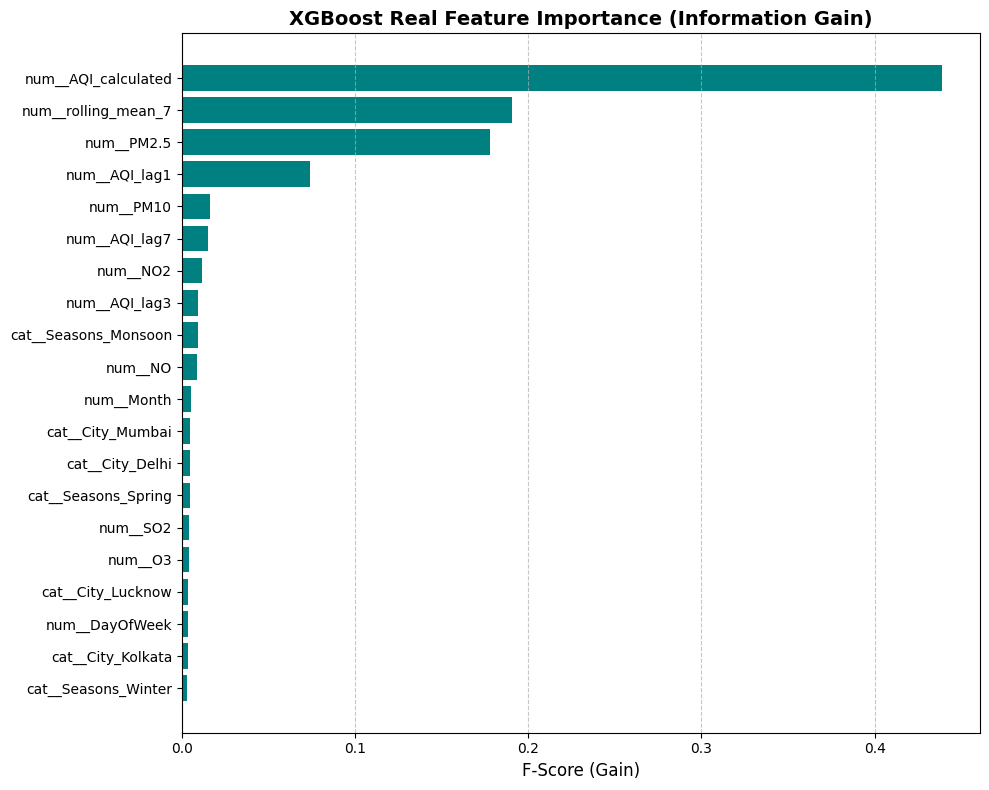

In [23]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

pipeline = joblib.load('aqi_pipeline_v2.pkl')

preprocessor = pipeline.steps[0][1]
xgb_model = pipeline.steps[-1][1]         


feature_names = preprocessor.get_feature_names_out()


importances = xgb_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Gain': importances
}).sort_values(by='Gain', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'].tail(20), importance_df['Gain'].tail(20), color='teal')
plt.title("XGBoost Real Feature Importance (Information Gain)", fontsize=14, fontweight='bold')
plt.xlabel("F-Score (Gain)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()